# Visualize Training Data with Augmentations

This notebook visualizes samples from the training dataset with and without augmentations to verify the augmentation pipeline is working correctly.

In [1]:
import sys
sys.path.append('..')

import matplotlib.pyplot as plt
import numpy as np
import torch
from pathlib import Path

from landslide.data import LandslideDataset
from landslide.utils import yaml_load

## Load Configuration

In [3]:
# Load config
config_path = '../config/base.yml'
dataset_path = '../data/processed/csv_split/A19_5cm.yml'

config = yaml_load(config_path)['params']

# Convert dict to object for attribute access
class Config:
    def __init__(self, d):
        for k, v in d.items():
            setattr(self, k, v)

config = Config(config)

print("Augmentation parameters:")
print(f"  Mosaic: {config.mosaic}")
print(f"  MixUp: {config.mixup}")
print(f"  CutMix: {config.cutmix}")
print(f"  CopyPaste: {config.copy_paste}")
print(f"  HSV: h={config.hsv_h}, s={config.hsv_s}, v={config.hsv_v}")
print(f"  Flips: horizontal={config.fliplr}, vertical={config.flipud}")

Augmentation parameters:
  Mosaic: 1.0
  MixUp: 0.0
  CutMix: 0.0
  CopyPaste: 0.0
  HSV: h=0.015, s=0.7, v=0.4
  Flips: horizontal=0.5, vertical=0.0


## Create Datasets

In [4]:
# Dataset with augmentations
dataset_aug = LandslideDataset(
    path=dataset_path,
    image_sz=512,
    mask_sz=128,
    do_resize=True,
    do_normalize=False,
    split='train',
    config=config
)

# Dataset without augmentations
dataset_no_aug = LandslideDataset(
    path=dataset_path,
    image_sz=512,
    mask_sz=128,
    do_resize=True,
    do_normalize=False,
    split='train',
    config=None
)

print(f"Dataset size: {len(dataset_aug)} samples")

Loading train dataset from ../data/processed/csv_split/A19_5cm.yml with root at /Users/gianlucacalo/Desktop/projects/landslide/data/raw/land-anomalies
Loading train dataset from ../data/processed/csv_split/A19_5cm.yml with root at /Users/gianlucacalo/Desktop/projects/landslide/data/raw/land-anomalies
Dataset size: 13717 samples


## Visualization Helper Functions

In [5]:
def tensor_to_numpy(tensor):
    """Convert tensor to numpy for visualization."""
    if isinstance(tensor, torch.Tensor):
        # (C, H, W) -> (H, W, C)
        if tensor.ndim == 3 and tensor.shape[0] in [1, 3]:
            tensor = tensor.permute(1, 2, 0)
        return tensor.cpu().numpy()
    return tensor

def plot_sample(img, mask, title="Sample"):
    """Plot image and mask side by side."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Convert tensors to numpy if needed
    img = tensor_to_numpy(img)
    mask = tensor_to_numpy(mask)
    
    # Normalize image to [0, 1] if needed
    if img.max() > 1.0:
        img = img / 255.0
    
    # Handle mask - squeeze if needed
    if mask.ndim == 3 and mask.shape[-1] == 1:
        mask = mask.squeeze(-1)
    if mask.max() > 1.0:
        mask = mask / 255.0
    
    # Image
    axes[0].imshow(img)
    axes[0].set_title('Image')
    axes[0].axis('off')
    
    # Mask
    axes[1].imshow(mask, cmap='gray')
    axes[1].set_title('Mask')
    axes[1].axis('off')
    
    # Overlay
    axes[2].imshow(img)
    axes[2].imshow(mask, cmap='Reds', alpha=0.5)
    axes[2].set_title('Overlay')
    axes[2].axis('off')
    
    fig.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

def plot_comparison(idx, dataset_no_aug, dataset_aug):
    """Plot original vs augmented side by side."""
    # Get samples
    sample_no_aug = dataset_no_aug[idx]
    sample_aug = dataset_aug[idx]
    
    img_no_aug = tensor_to_numpy(sample_no_aug['input'])
    mask_no_aug = tensor_to_numpy(sample_no_aug['target'])
    img_aug = tensor_to_numpy(sample_aug['input'])
    mask_aug = tensor_to_numpy(sample_aug['target'])
    
    # Normalize
    if img_no_aug.max() > 1.0:
        img_no_aug = img_no_aug / 255.0
    if img_aug.max() > 1.0:
        img_aug = img_aug / 255.0
    if mask_no_aug.max() > 1.0:
        mask_no_aug = mask_no_aug / 255.0
    if mask_aug.max() > 1.0:
        mask_aug = mask_aug / 255.0
    
    # Handle mask dimensions
    if mask_no_aug.ndim == 3:
        mask_no_aug = mask_no_aug.squeeze(-1) if mask_no_aug.shape[-1] == 1 else mask_no_aug[:, :, 0]
    if mask_aug.ndim == 3:
        mask_aug = mask_aug.squeeze(-1) if mask_aug.shape[-1] == 1 else mask_aug[:, :, 0]
    
    # Plot
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # Original
    axes[0, 0].imshow(img_no_aug)
    axes[0, 0].set_title('Original Image')
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(mask_no_aug, cmap='gray')
    axes[0, 1].set_title('Original Mask')
    axes[0, 1].axis('off')
    
    axes[0, 2].imshow(img_no_aug)
    axes[0, 2].imshow(mask_no_aug, cmap='Reds', alpha=0.5)
    axes[0, 2].set_title('Original Overlay')
    axes[0, 2].axis('off')
    
    # Augmented
    axes[1, 0].imshow(img_aug)
    axes[1, 0].set_title('Augmented Image')
    axes[1, 0].axis('off')
    
    axes[1, 1].imshow(mask_aug, cmap='gray')
    axes[1, 1].set_title('Augmented Mask')
    axes[1, 1].axis('off')
    
    axes[1, 2].imshow(img_aug)
    axes[1, 2].imshow(mask_aug, cmap='Reds', alpha=0.5)
    axes[1, 2].set_title('Augmented Overlay')
    axes[1, 2].axis('off')
    
    fig.suptitle(f'Sample {idx}: Original vs Augmented', fontsize=16)
    plt.tight_layout()
    plt.show()

## View Single Sample (Multiple Times to See Variation)

Viewing sample 0 with 5 different augmentations:


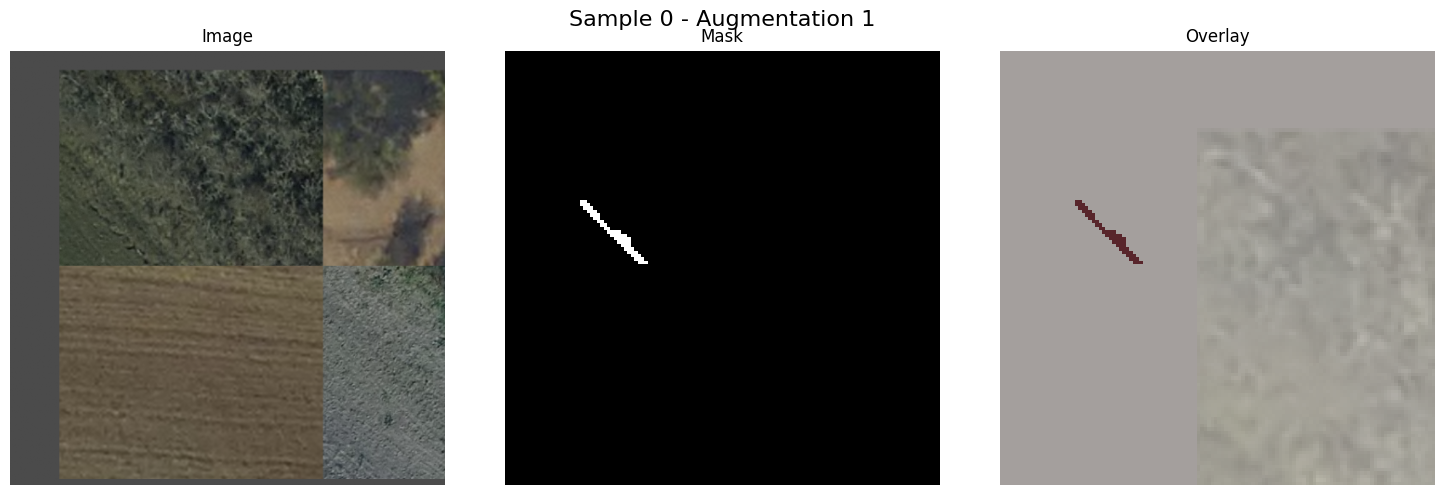

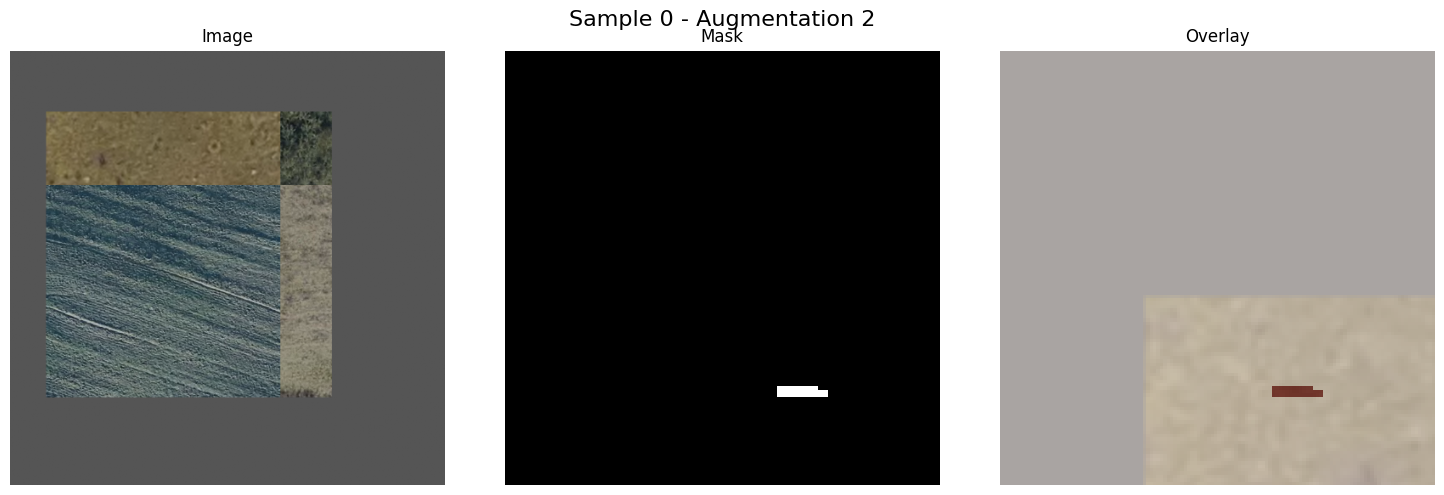

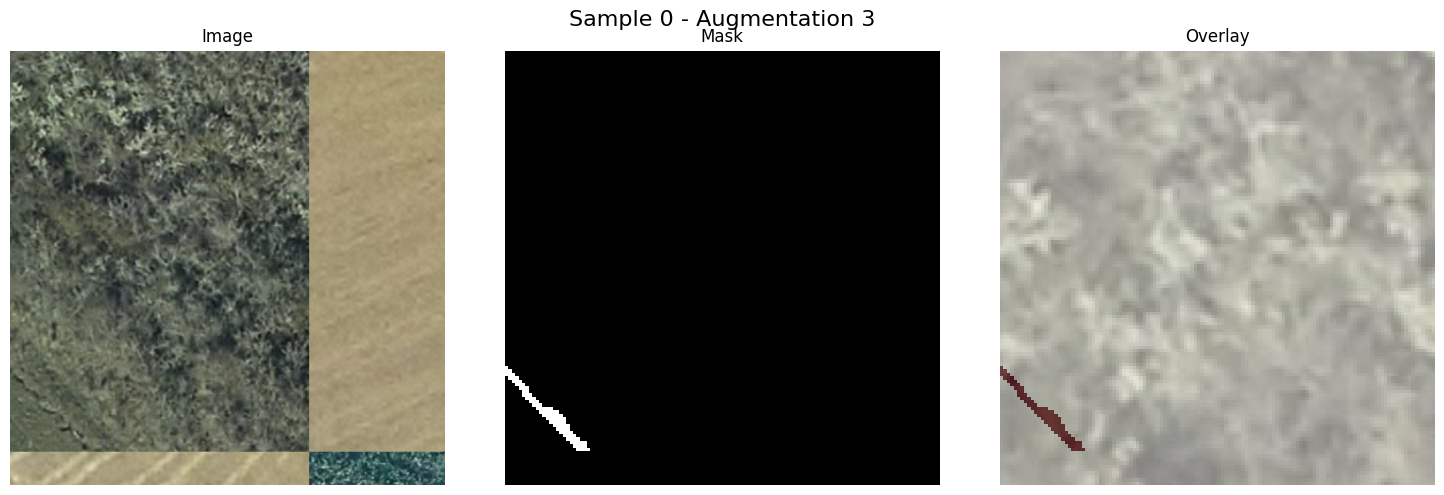

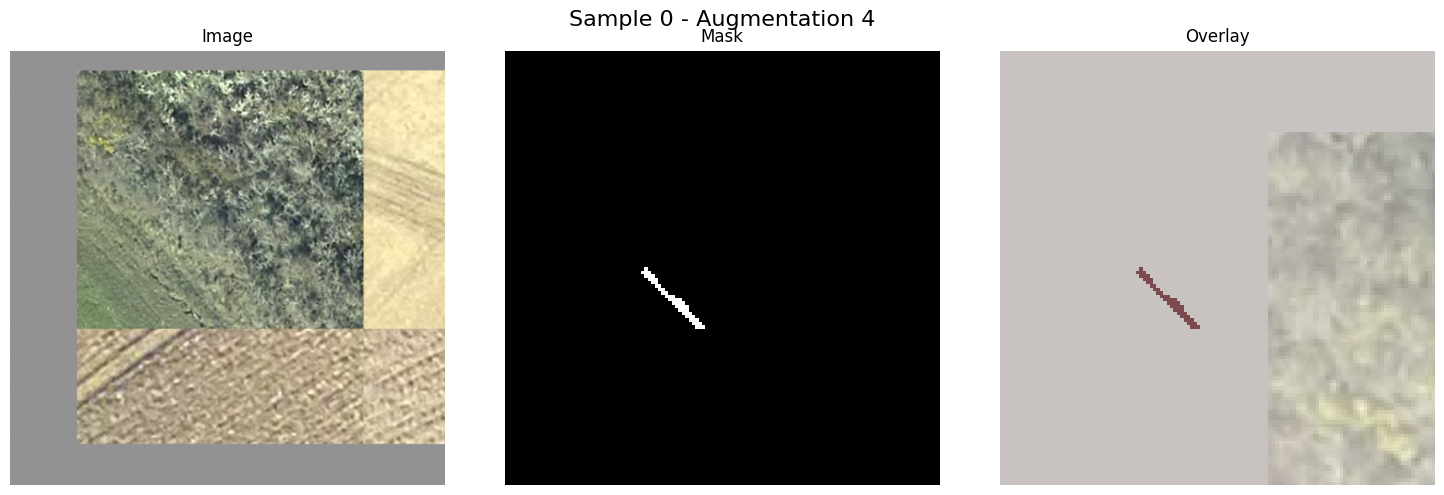

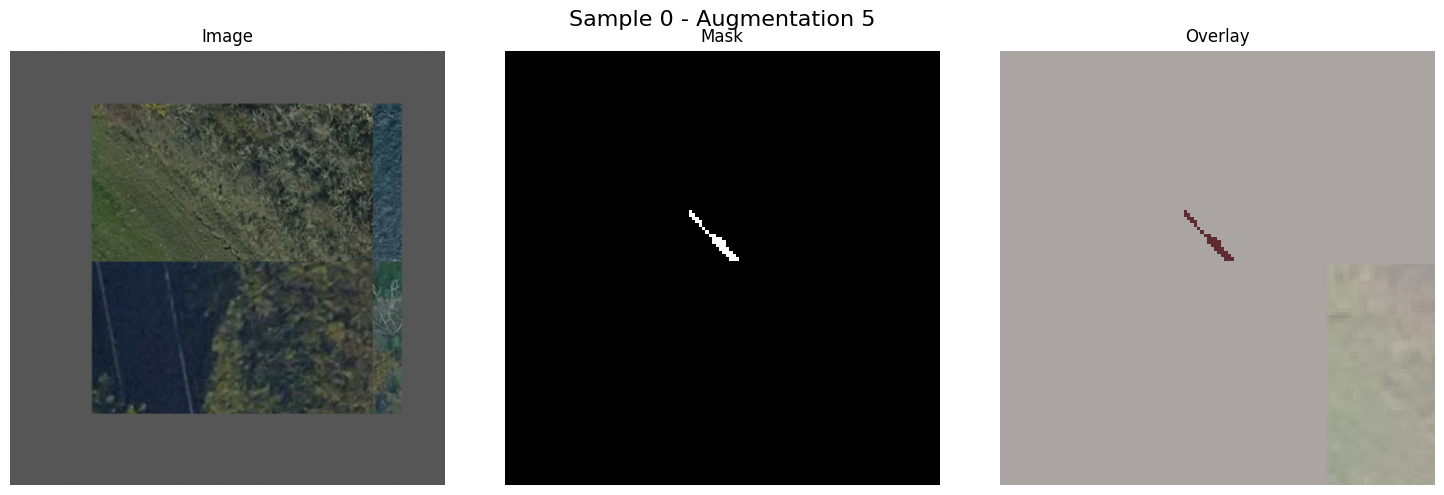

In [6]:
# View same sample multiple times to see augmentation variation
sample_idx = 0

print(f"Viewing sample {sample_idx} with 5 different augmentations:")
for i in range(5):
    sample = dataset_aug[sample_idx]
    plot_sample(sample['input'], sample['target'], title=f"Sample {sample_idx} - Augmentation {i+1}")

## Compare Original vs Augmented

Comparing 5 samples (original vs augmented):


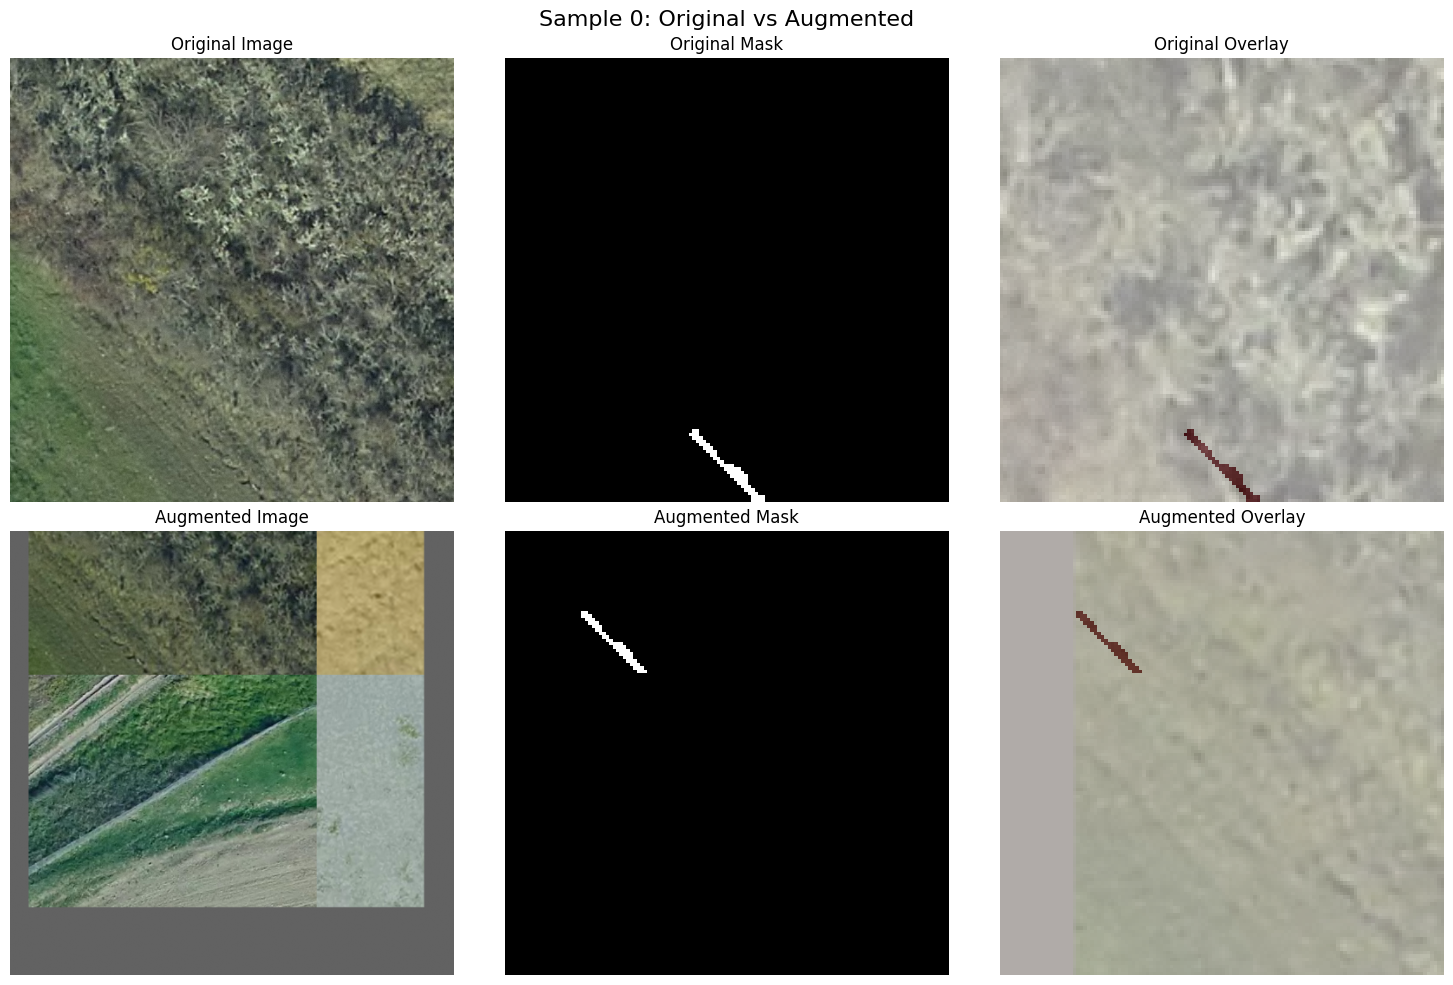

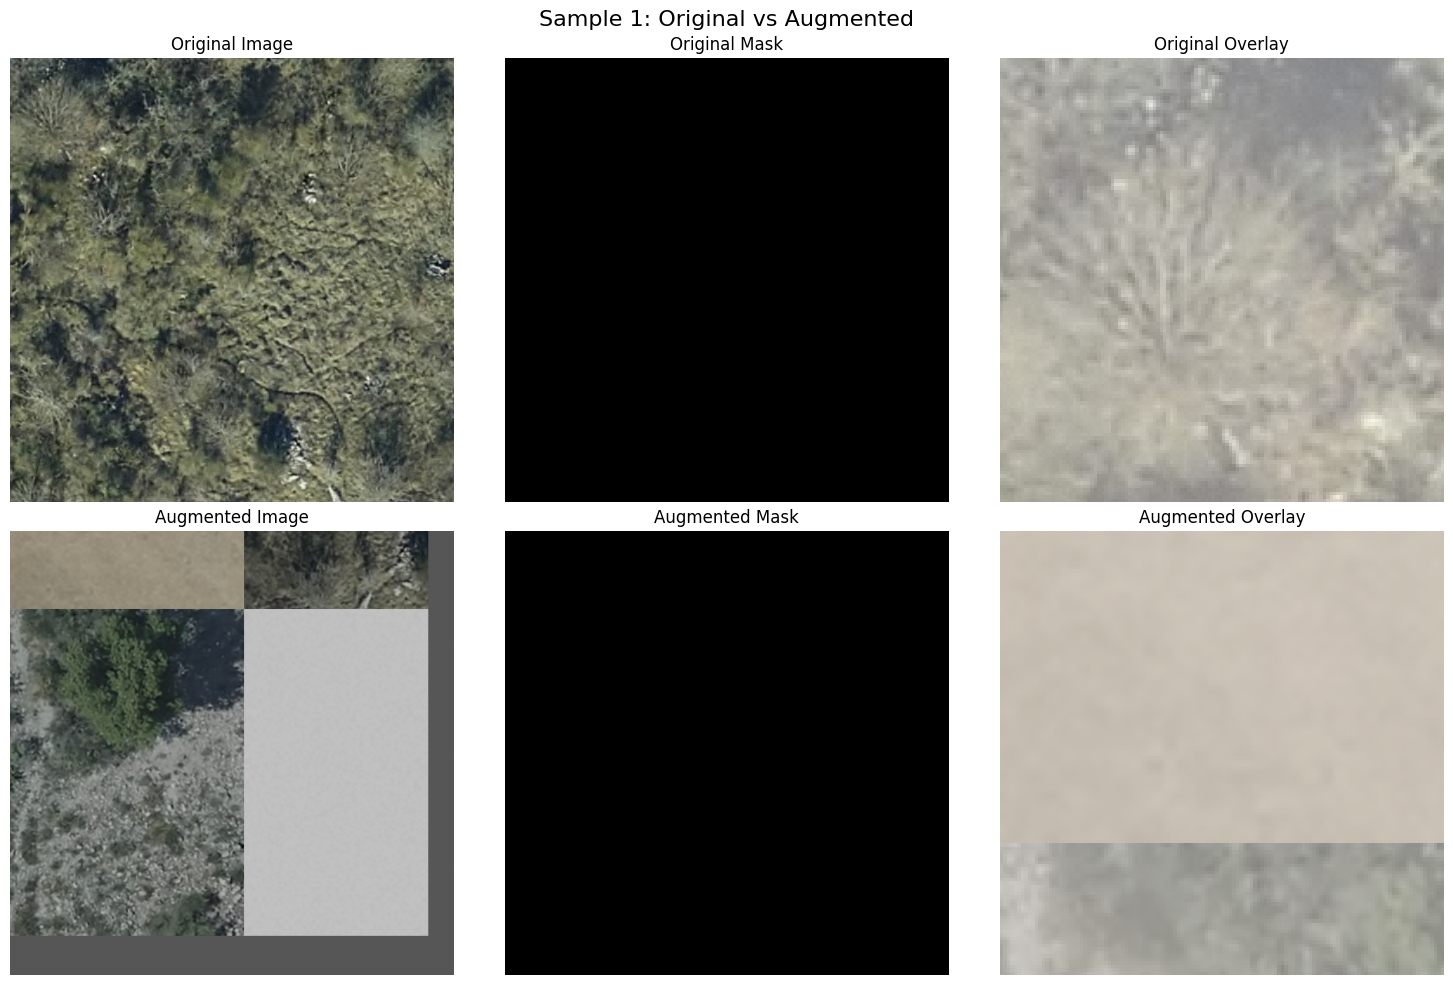

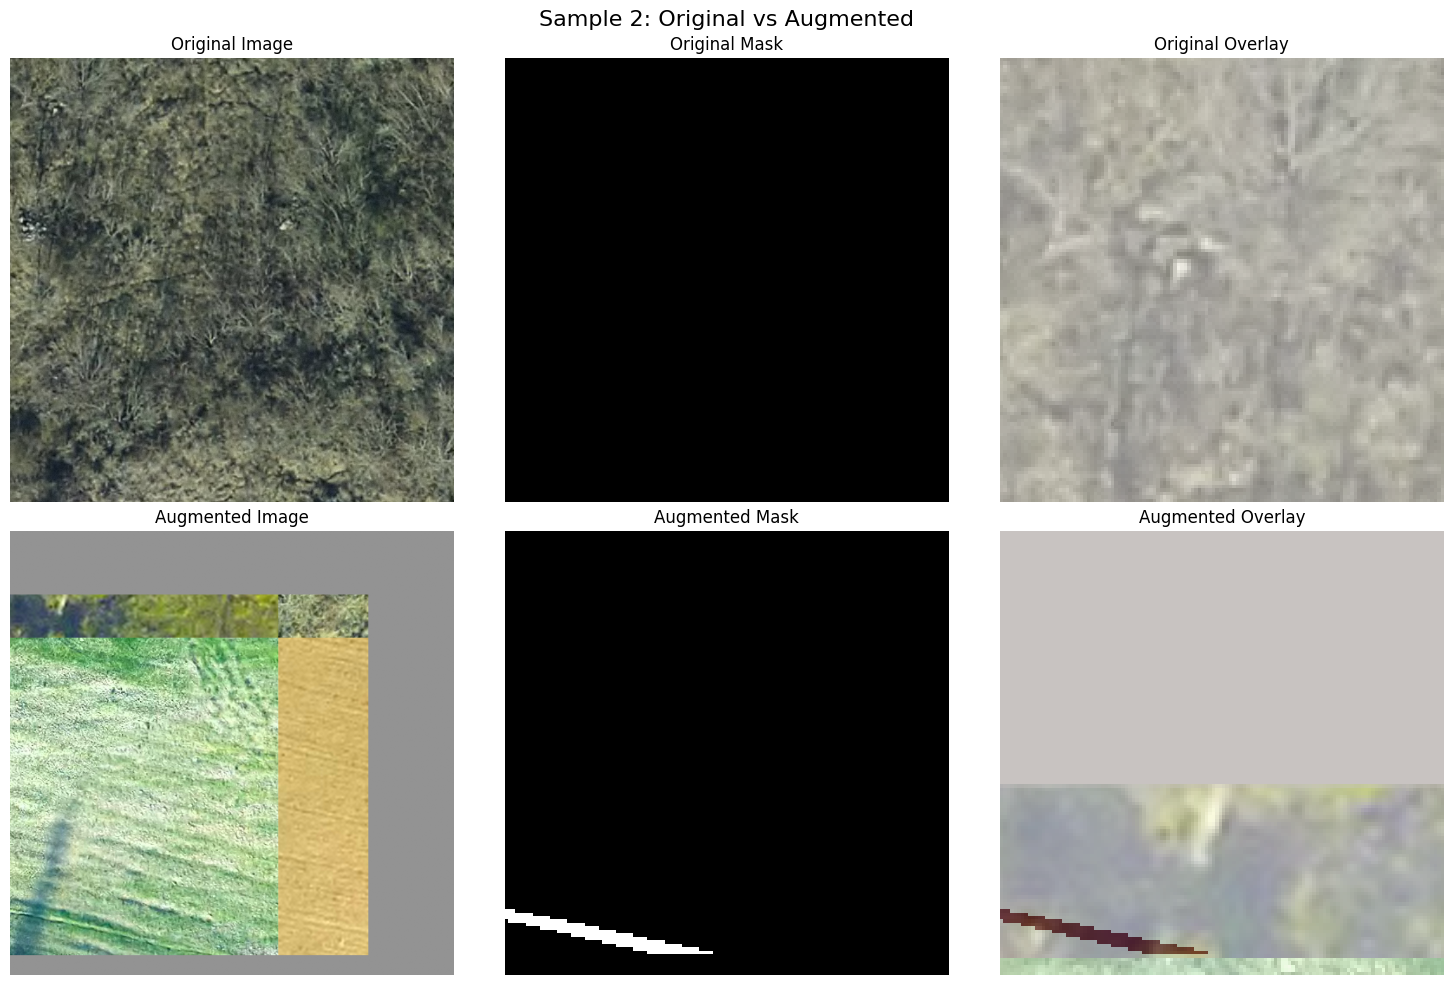

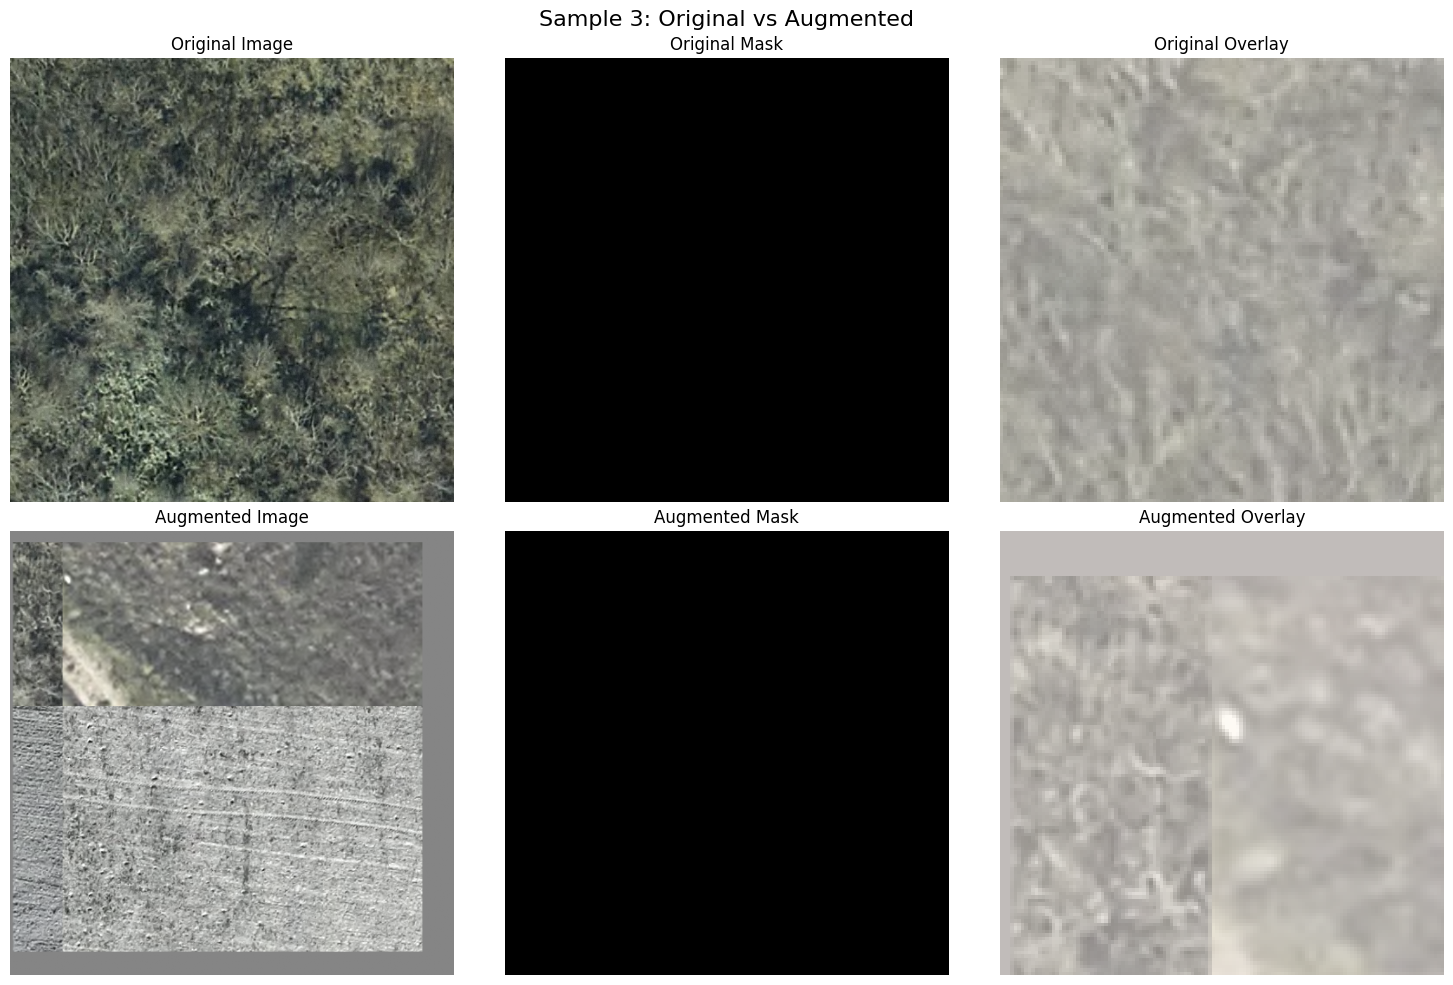

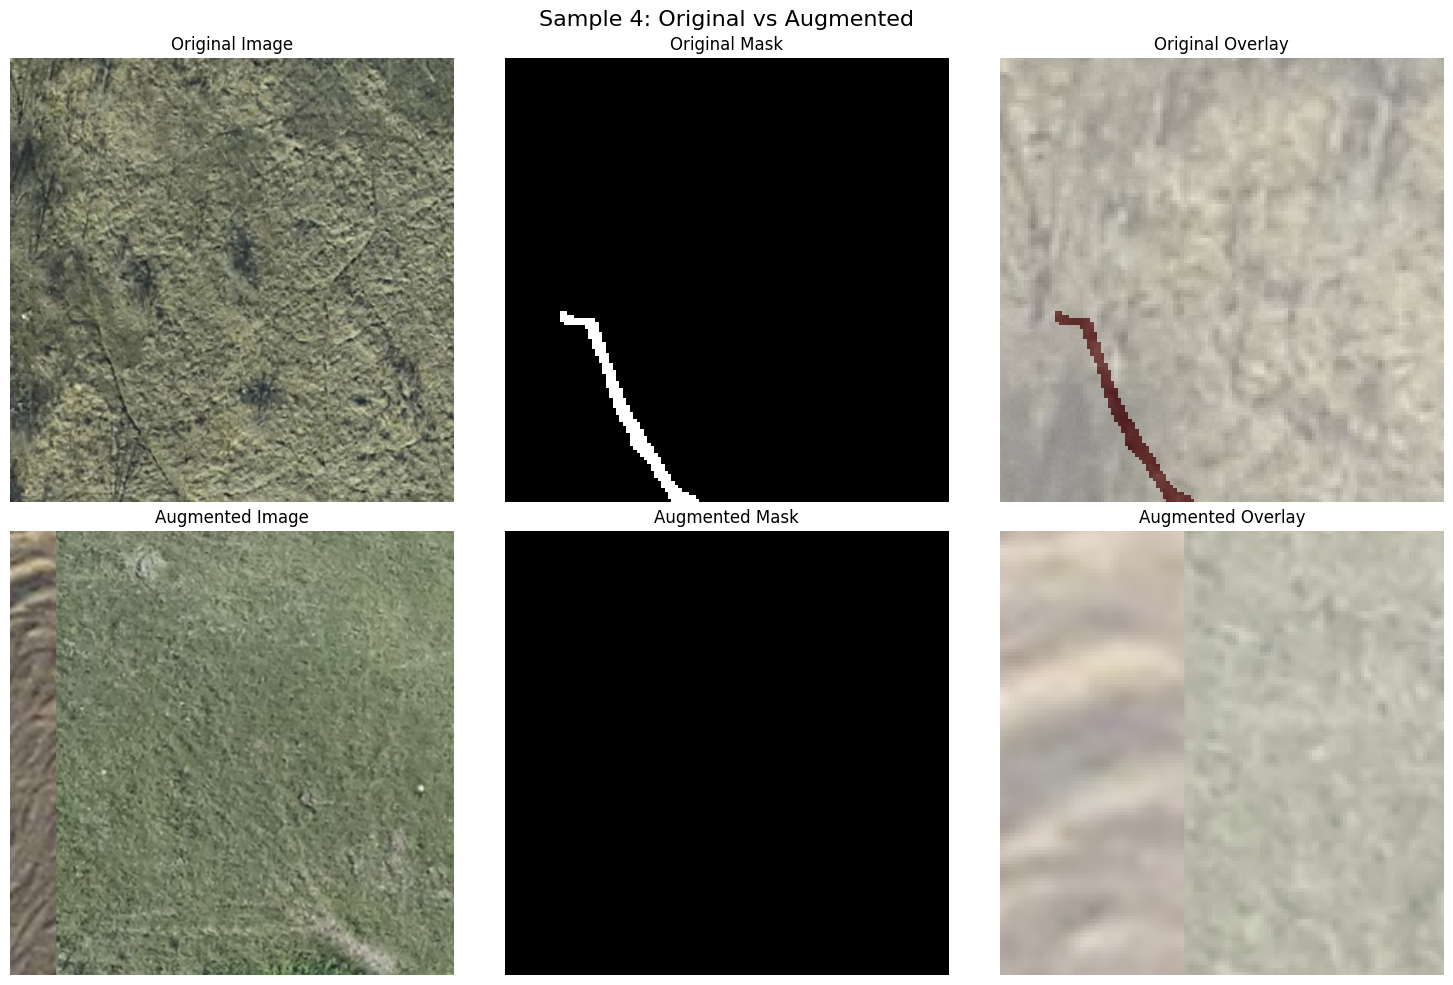

In [7]:
# Compare multiple samples
num_samples = 5
print(f"Comparing {num_samples} samples (original vs augmented):")

for idx in range(num_samples):
    plot_comparison(idx, dataset_no_aug, dataset_aug)

## View Random Batch

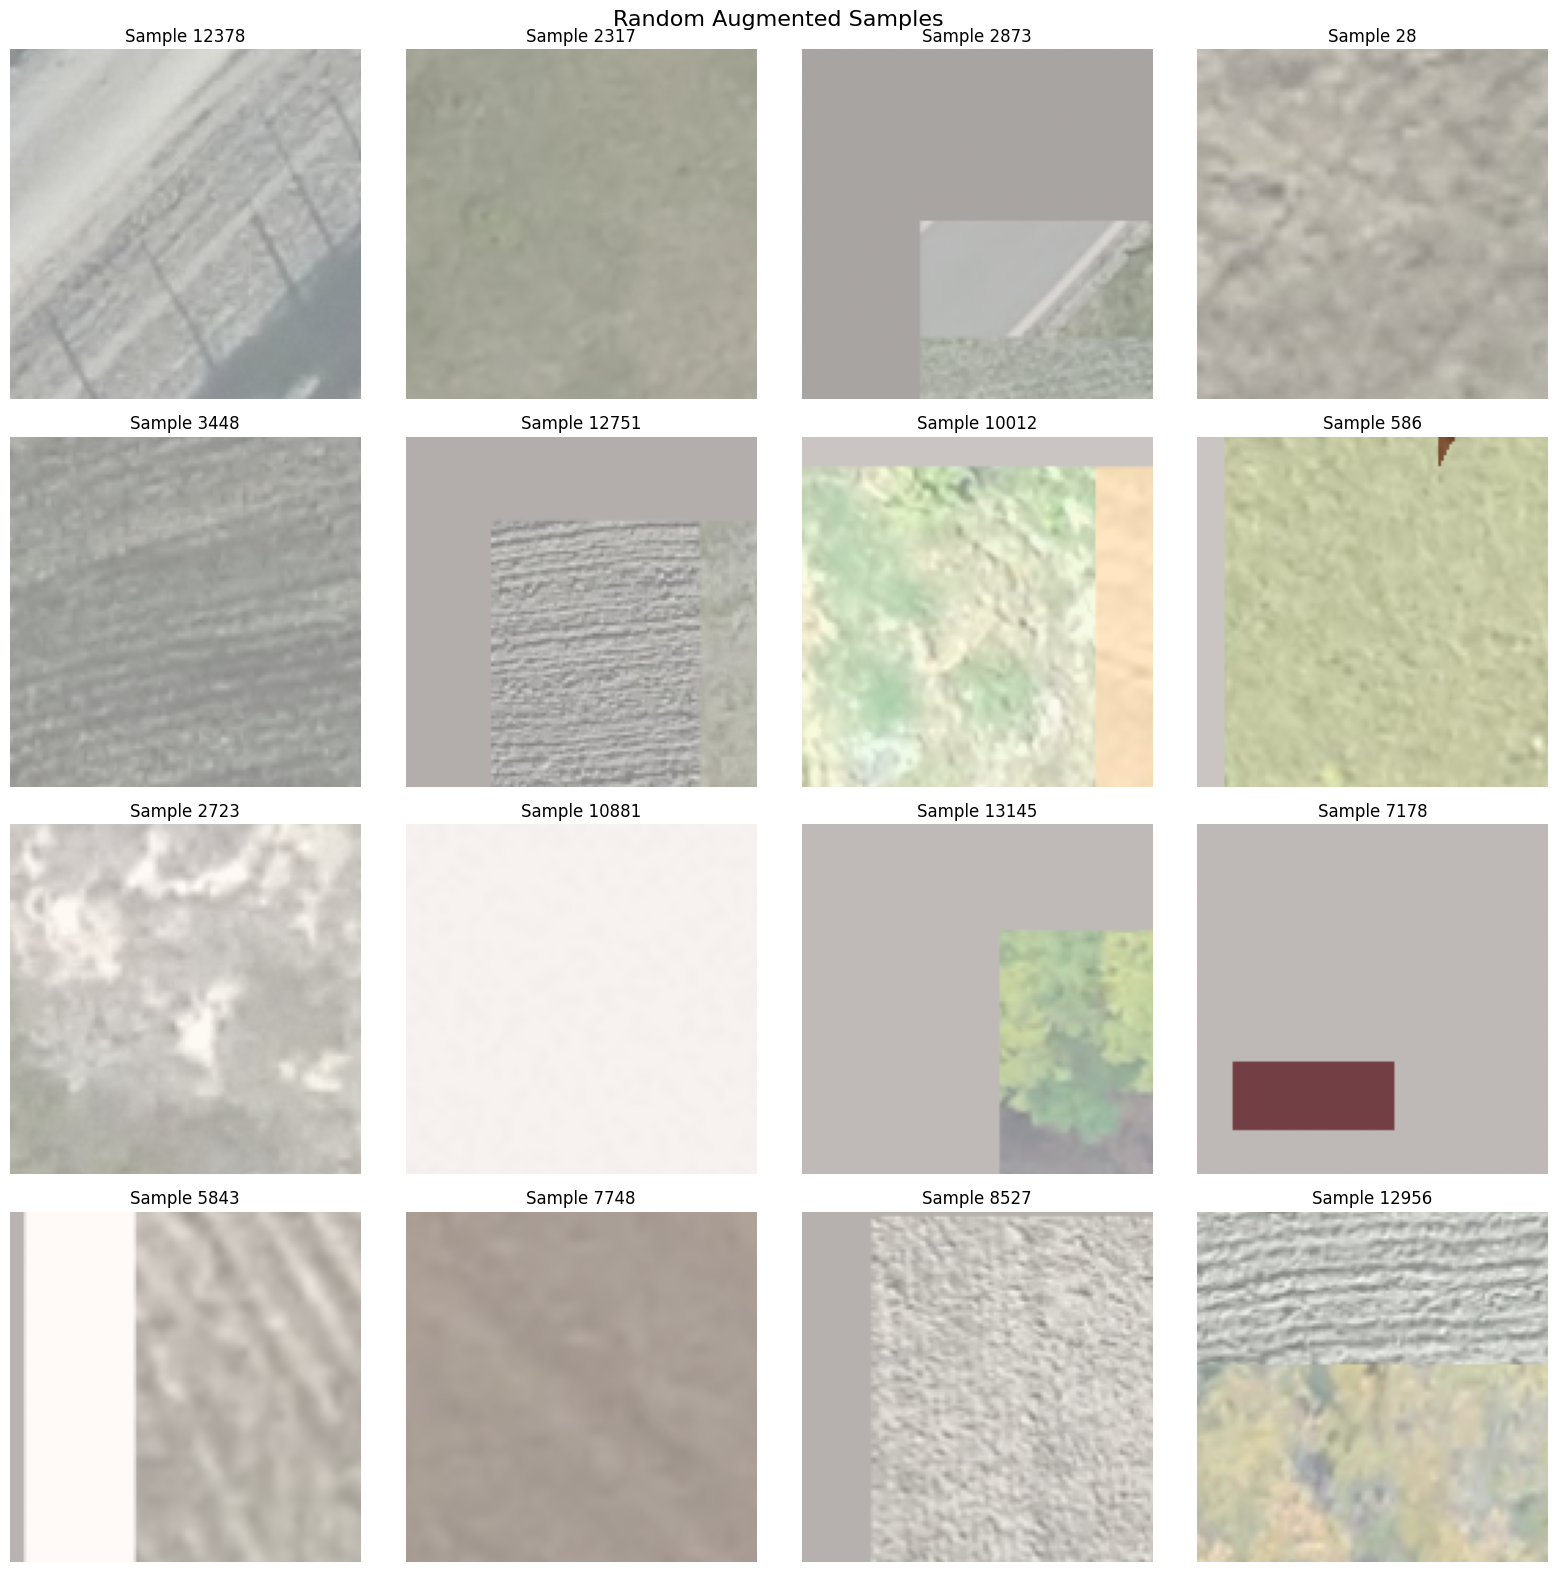

In [8]:
# View random samples in a grid
import random

num_samples = 16
indices = random.sample(range(len(dataset_aug)), num_samples)

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
axes = axes.flatten()

for i, idx in enumerate(indices):
    sample = dataset_aug[idx]
    img = tensor_to_numpy(sample['input'])
    mask = tensor_to_numpy(sample['target'])
    
    # Normalize
    if img.max() > 1.0:
        img = img / 255.0
    if mask.max() > 1.0:
        mask = mask / 255.0
    
    # Handle mask dimensions
    if mask.ndim == 3:
        mask = mask.squeeze(-1) if mask.shape[-1] == 1 else mask[:, :, 0]
    
    # Plot overlay
    axes[i].imshow(img)
    axes[i].imshow(mask, cmap='Reds', alpha=0.5)
    axes[i].set_title(f'Sample {idx}')
    axes[i].axis('off')

fig.suptitle('Random Augmented Samples', fontsize=16)
plt.tight_layout()
plt.show()

## Test Specific Augmentations

To test individual augmentations, you can temporarily modify the config or create custom augmentation pipelines.

In [ ]:
# Test with only Mosaic enabled
config_mosaic_only = Config({
    'mosaic': 1.0,
    'mixup': 0.0,
    'cutmix': 0.0,
    'copy_paste': 0.0,
    'hsv_h': 0.0,
    'hsv_s': 0.0,
    'hsv_v': 0.0,
    'fliplr': 0.0,
    'flipud': 0.0,
    'degrees': 0.0,
    'translate': 0.0,
    'scale': 0.0,
    'shear': 0.0,
    'perspective': 0.0,
    'copy_paste_mode': 'flip'
})

dataset_mosaic = LandslideDataset(
    path=dataset_path,
    image_sz=512,
    mask_sz=128,
    do_resize=True,
    do_normalize=False,
    split='train',
    config=config_mosaic_only
)

print("Testing Mosaic augmentation only:")
for i in range(3):
    sample = dataset_mosaic[0]
    plot_sample(sample['input'], sample['target'], title=f"Mosaic Only - Variation {i+1}")

## Statistics

Check basic statistics of augmented data.

In [ ]:
# Collect statistics from random samples
num_samples = 100
indices = random.sample(range(len(dataset_aug)), num_samples)

img_means = []
img_stds = []
mask_ratios = []  # Ratio of positive pixels

for idx in indices:
    sample = dataset_aug[idx]
    img = tensor_to_numpy(sample['input'])
    mask = tensor_to_numpy(sample['target'])
    
    # Normalize to [0, 1]
    if img.max() > 1.0:
        img = img / 255.0
    if mask.max() > 1.0:
        mask = mask / 255.0
    
    img_means.append(img.mean())
    img_stds.append(img.std())
    mask_ratios.append((mask > 0.5).mean())

print(f"Statistics from {num_samples} augmented samples:")
print(f"Image mean: {np.mean(img_means):.4f} ± {np.std(img_means):.4f}")
print(f"Image std: {np.mean(img_stds):.4f} ± {np.std(img_stds):.4f}")
print(f"Mask positive ratio: {np.mean(mask_ratios):.4f} ± {np.std(mask_ratios):.4f}")

# Plot distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(img_means, bins=30, edgecolor='black')
axes[0].set_title('Image Mean Distribution')
axes[0].set_xlabel('Mean')
axes[0].set_ylabel('Frequency')

axes[1].hist(img_stds, bins=30, edgecolor='black')
axes[1].set_title('Image Std Distribution')
axes[1].set_xlabel('Std')
axes[1].set_ylabel('Frequency')

axes[2].hist(mask_ratios, bins=30, edgecolor='black')
axes[2].set_title('Mask Positive Ratio Distribution')
axes[2].set_xlabel('Ratio')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()